## Import Dependencies

In [1]:
import os
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches

# House visualization standard (kick_style lives in football_visuals/)
sys.path.insert(0, str(Path().resolve().parents[0]))
from football_visuals.kick_style import *
apply_kick_style()

## Data Preprocessing

In [2]:
# 12 rows x 16 columns grid
XT_GRID = np.array([
    [0.001, 0.002, 0.002, 0.003, 0.003, 0.004, 0.005, 0.006, 0.007, 0.009, 0.011, 0.013, 0.016, 0.017, 0.017, 0.016],
    [0.002, 0.002, 0.003, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.010, 0.012, 0.015, 0.018, 0.021, 0.020, 0.021],
    [0.002, 0.003, 0.003, 0.004, 0.004, 0.005, 0.006, 0.007, 0.009, 0.010, 0.013, 0.016, 0.021, 0.025, 0.027, 0.024],
    [0.002, 0.003, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.011, 0.014, 0.018, 0.024, 0.029, 0.039, 0.031],
    [0.003, 0.003, 0.004, 0.004, 0.005, 0.006, 0.007, 0.008, 0.010, 0.011, 0.014, 0.019, 0.027, 0.055, 0.091, 0.071],
    [0.004, 0.004, 0.004, 0.004, 0.005, 0.006, 0.007, 0.008, 0.010, 0.012, 0.014, 0.019, 0.033, 0.077, 0.142, 0.332],
    [0.004, 0.004, 0.004, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.012, 0.014, 0.020, 0.034, 0.085, 0.134, 0.320],
    [0.004, 0.003, 0.004, 0.004, 0.005, 0.006, 0.007, 0.008, 0.010, 0.012, 0.014, 0.020, 0.028, 0.062, 0.095, 0.085],
    [0.002, 0.003, 0.004, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.011, 0.014, 0.018, 0.025, 0.035, 0.042, 0.033],
    [0.002, 0.003, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.011, 0.013, 0.017, 0.021, 0.026, 0.026, 0.022],
    [0.002, 0.002, 0.003, 0.003, 0.004, 0.005, 0.006, 0.007, 0.009, 0.010, 0.013, 0.016, 0.019, 0.021, 0.020, 0.020],
    [0.001, 0.002, 0.002, 0.003, 0.004, 0.004, 0.005, 0.007, 0.008, 0.009, 0.012, 0.014, 0.016, 0.018, 0.017, 0.017]
])

# Pitch Dimensions
SB_WIDTH = 120
SB_HEIGHT = 80
ROWS, COLS = XT_GRID.shape

In [3]:
def _load_events_raw(match_id, base_path):
    event_path = os.path.join(base_path, f"events/{match_id}.json")
    with open(event_path, "r") as f:
        events_raw = json.load(f)
    return events_raw

In [4]:
def _extract_shot_features(df_events):
    df_shots = df_events[df_events["type_name"] == "Shot"].copy()
    
    if not df_shots.empty:
        target_cols = {
            'id': 'shot_id_temp',
            'shot_statsbomb_xg': 'assisted_shot_xg',
            'shot_outcome_name': 'assisted_shot_outcome'
        }
        return df_shots[list(target_cols.keys())].rename(columns=target_cols)
    
    # Return empty structure if no shots found
    return pd.DataFrame(columns=['shot_id_temp', 'assisted_shot_xg', 'assisted_shot_outcome'])

The function `load_passes` serves as a standardized processing engine to convert raw StatsBomb JSON events into an analysis-ready format. It follows a multi-stage pipeline designed for modularity and future research extensibility.

| **Stage** | **Process** | **Research Utility** |
|---|---|---|
| Feature Extraction | Isolate "Pass" events and utilize a helper function to retrieve associated Shot xG and outcomes. | Allows for "Pass-to-Shot" dependency analysis and Shot-Assist quality metrics. |
| Attribute Filtering | Selects a standardized subset of tactical markers (e.g., `pass_cross`, `pass_technique_name`). | Maintains a lightweight DataFrame while preserving latent variables for future categorical analysis. |
| Coordinate Normalization | Unpacks nested location lists into discrete (x,y) and (end_x,end_y) vectors. | Essential for heatmapping, distance calculations, and geometric formation analysis. |
| Spatial Threat Mapping | Vectorized lookup against a 12x16 xT Matrix to calculate the Threat Delta (ΔxT). | Quantifies the progressive value of possession beyond traditional completion percentages. |

In [5]:
def load_passes(match_id, base_path):
    events_raw = _load_events_raw(match_id, base_path)
    df_events = pd.json_normalize(events_raw, sep="_")
    
    # Extract and Format Shot Data 
    df_shots = _extract_shot_features(df_events)

    # Filter Passes & Select Columns
    df_passes = df_events[df_events["type_name"] == "Pass"].copy()
    
    desired_columns = [
        "id", "period", "timestamp", "minute", "second","team_name", "player_id", "player_name", 
        "pass_recipient_id", "pass_recipient_name", "location", "pass_end_location",
        "pass_length", "pass_angle", "pass_height_name", "pass_assisted_shot_id", 
        "pass_backheel", "pass_deflected", "pass_miscommunication", "pass_cross", 
        "pass_cut_back", "pass_switch", "pass_shot_assist", "pass_goal_assist", 
        "pass_body_part_name", "pass_type_name", "pass_outcome_name", "pass_technique_name"
    ]
    
    existing_cols = [col for col in desired_columns if col in df_passes.columns]
    df_passes = df_passes[existing_cols].copy()

    # Merges Shots and Passes
    if "pass_assisted_shot_id" in df_passes.columns:
        df_passes = df_passes.merge(df_shots, left_on='pass_assisted_shot_id', right_on='shot_id_temp', how='left').drop(columns=['shot_id_temp'])
    else:
        df_passes[['assisted_shot_xg', 'assisted_shot_outcome']] = None

    # Unpack Coordinates
    if "location" in df_passes.columns:
        df_passes[['x', 'y']] = pd.DataFrame(df_passes['location'].tolist(), index=df_passes.index)
        df_passes[['end_x', 'end_y']] = pd.DataFrame(df_passes['pass_end_location'].tolist(), index=df_passes.index)

    # Calculate Expected Threat (xT)
    if all(col in df_passes.columns for col in ['x', 'y', 'end_x', 'end_y']):
        x_bins = np.clip(np.floor(df_passes['x'] / SB_WIDTH * COLS).astype(int), 0, COLS - 1)
        y_bins = np.clip(np.floor(df_passes['y'] / SB_HEIGHT * ROWS).astype(int), 0, ROWS - 1)
        
        end_x_bins = np.clip(np.floor(df_passes['end_x'] / SB_WIDTH * COLS).astype(int), 0, COLS - 1)
        end_y_bins = np.clip(np.floor(df_passes['end_y'] / SB_HEIGHT * ROWS).astype(int), 0, ROWS - 1)

        start_xt = XT_GRID[y_bins, x_bins]
        end_xt = XT_GRID[end_y_bins, end_x_bins]
        df_passes['pass_xt'] = end_xt - start_xt

    return df_passes

We load lineups to map unique StatsBomb identifiers to descriptive player attributes, ensuring better visualizations. 

In [6]:
def load_lineups(match_id, base_path):
    lineup_path = os.path.join(base_path, f"lineups/{match_id}.json")
    
    with open(lineup_path, "r") as f:
        lineups_raw = json.load(f)
        
    lineup_list = []
    for team in lineups_raw:
        team_name = team["team_name"]
        for player in team["lineup"]:
            player_info = {
                "team_name": team_name,
                "player_id": player["player_id"],
                "player_name": player["player_name"],
                "player_nickname": player.get("player_nickname"),
                "jersey_number": player["jersey_number"],
                "country": player["country"]["name"]
            }
            lineup_list.append(player_info)
            
    df_lineups = pd.DataFrame(lineup_list)
    return df_lineups

In constructing a passing network, the primary objective is to visualize the intended tactical structure of a team. To ensure the integrity of this visualization, we apply a "First Sub" cutoff logic, which restricts the dataset to the period between kick-off and the first structural change (substitution or dismissal).

Therefore, here we made a "chronological governor" of the data. It establishes the timeline of the match to determine exactly when each player was active.

| **Component** | **Logic Applied** |
| --- | --- |
| Starters | Identifies the 22 players in the `Starting XI` events and initializes their start time to 00:00. |
| Substitutions | Triggers a dual update: records the exit time for the player going off and initializes a new entry for the player coming on. |
| Disciplinary Exits | Scans for `Red Card` or `Second Yellow` events to force an early exit time for the penalized player. |
| Match Ceiling | Identifies the final recorded event time to serve as the default exit for all players still on the pitch. |

In [7]:
def load_appearances(match_id, base_path):
    events_raw = _load_events_raw(match_id, base_path)
    df_events = pd.json_normalize(events_raw, sep="_")
    
    # Match End Ceiling
    max_idx = df_events['minute'].idxmax()
    match_end = {
        'minute': df_events.loc[max_idx, 'minute'],
        'second': df_events.loc[max_idx, 'second'],
        'period': df_events.loc[max_idx, 'period'],
        'timestamp': df_events.loc[max_idx, 'timestamp']
    }
    
    appearances = {}
    
    # A: Starters
    starters = df_events[df_events['type_name'] == 'Starting XI']
    match_start_ts = df_events.loc[0, 'timestamp']
    
    for _, event in starters.iterrows():
        raw_event = [e for e in events_raw if e['id'] == event['id']][0]
        for player in raw_event['tactics']['lineup']:
            p_id = player['player']['id']
            appearances[p_id] = {
                'player_name': player['player']['name'],
                'team_name': event['team_name'],
                'start_minute': 0, 'start_second': 0, 'start_period': 1,
                'start_timestamp': match_start_ts,
                'end_minute': match_end['minute'], 'end_second': match_end['second'],
                'end_period': match_end['period'], 'end_timestamp': match_end['timestamp'],
                'status': 'Starter'
            }

    # B: Substitutions
    subs = df_events[df_events['type_name'] == 'Substitution']
    for _, event in subs.iterrows():
        p_off = event['player_id']
        p_in = event['substitution_replacement_id']
        
        # Player OFF: Update End Time
        if p_off in appearances:
            appearances[p_off].update({
                'end_minute': event['minute'], 'end_second': event['second'],
                'end_period': event['period'], 'end_timestamp': event['timestamp']
            })
            
        # Player ON: Create New Entry
        appearances[p_in] = {
            'player_name': event['substitution_replacement_name'],
            'team_name': event['team_name'],
            'start_minute': event['minute'], 'start_second': event['second'],
            'start_period': event['period'], 'start_timestamp': event['timestamp'],
            'end_minute': match_end['minute'], 'end_second': match_end['second'],
            'end_period': match_end['period'], 'end_timestamp': match_end['timestamp'],
            'status': 'Sub'
        }

    # C: Red Cards
    card_cols = ['bad_behaviour_card_name', 'foul_committed_card_name']
    valid_card_cols = [c for c in card_cols if c in df_events.columns]
    
    for col in valid_card_cols:
        reds = df_events[df_events[col].isin(['Red Card', 'Second Yellow'])]
        for _, event in reds.iterrows():
            if event['player_id'] in appearances:
                appearances[event['player_id']].update({
                    'end_minute': event['minute'], 'end_second': event['second'],
                    'end_period': event['period'], 'end_timestamp': event['timestamp']
                })

    # D: Match Ceiling
    df_app = pd.DataFrame.from_dict(appearances, orient='index').reset_index().rename(columns={'index': 'player_id'})
    df_app['mins_played'] = df_app['end_minute'] - df_app['start_minute']
    
    return df_app

In [8]:
def prepare_filtered_passes(base_path, match_id, team_name=None):
    # Load the three core modules
    df_passes = load_passes(match_id, base_path)
    df_app = load_appearances(match_id, base_path)
    df_lineups = load_lineups(match_id, base_path)
    
    #  Resolve Team Name
    if team_name is None:
        team_name = df_lineups['team_name'].unique()[0]
    
    # Identify Starters and their earliest exit time
    mask_starters = (df_app['team_name'] == team_name) & (df_app['status'] == 'Starter')
    df_starters = df_app[mask_starters].copy()
    
    # Create time tuples (Period, Minute, Second) to find the exact cutoff
    df_starters['exit_time_tuple'] = list(zip(
        df_starters['end_period'], 
        df_starters['end_minute'], 
        df_starters['end_second']
    ))
    earliest_exit = df_starters['exit_time_tuple'].min()
    
    # Filter passes by Team, Player ID (Starters), and Time
    starter_ids = df_starters['player_id'].tolist()
    pass_time_tuples = list(zip(df_passes['period'], df_passes['minute'], df_passes['second']))
    is_before_cutoff = [t < earliest_exit for t in pass_time_tuples]
    
    df_passes_clean = df_passes[
        (df_passes['team_name'] == team_name) &
        (df_passes['player_id'].isin(starter_ids)) &
        (pd.Series(is_before_cutoff, index=df_passes.index))
    ].copy()
    
    return df_passes_clean

## Plot the Passing Network

In [9]:
def calculate_average_locations(df_passes_clean):
    # Metric Columns
    df_passes_clean['is_success'] = df_passes_clean['pass_outcome_name'].isna().astype(int)
    if 'pass_xt' not in df_passes_clean.columns:
        df_passes_clean['pass_xt'] = 0.0
    df_passes_clean['pass_xt'] = df_passes_clean['pass_xt'].fillna(0)

    # Main Aggregation
    df_nodes = df_passes_clean.groupby(['player_id', 'player_name']).agg({
        'x': 'mean',
        'y': 'mean',
        'id': 'count',              
        'is_success': 'sum',       
        'pass_xt': 'sum'            
    }).reset_index()

    df_nodes.rename(columns={'id': 'pass_count', 'is_success': 'success_count', 'pass_xt': 'total_xt'}, inplace=True)
    df_nodes['success_rate'] = df_nodes['success_count'] / df_nodes['pass_count']

    # Calculate Average Angle of FAILED Passes
    df_failed = df_passes_clean[df_passes_clean['is_success'] == 0].copy()
    
    if not df_failed.empty:
        # Convert radians to unit vectors (x, y) to handle circular averaging
        df_failed['fail_cos'] = np.cos(df_failed['pass_angle'])
        df_failed['fail_sin'] = np.sin(df_failed['pass_angle'])
        
        # Group by player and average the vectors
        fail_dirs = df_failed.groupby('player_id')[['fail_cos', 'fail_sin']].mean()
        
        # Convert back to degrees (StatsBomb 0 is East, 90 is North - matches MPL)
        fail_dirs['avg_fail_angle'] = np.degrees(np.arctan2(fail_dirs['fail_sin'], fail_dirs['fail_cos']))
        
        # Merge back to nodes
        df_nodes = df_nodes.merge(fail_dirs['avg_fail_angle'], on='player_id', how='left')
    else:
        df_nodes['avg_fail_angle'] = 0 # Default if match has 0 errors (rare)

    # Fill NaN angles (players with 100% success have no fail angle) with 0
    df_nodes['avg_fail_angle'] = df_nodes['avg_fail_angle'].fillna(0)
    
    return df_nodes

In [10]:
def calculate_edges_asymmetric(df_passes_clean):
    # Keep completed passes only — filter explicitly rather than relying
    # on failed passes carrying a NaN recipient
    df_success = df_passes_clean[
        df_passes_clean['pass_outcome_name'].isna() &
        df_passes_clean['pass_recipient_id'].notna()
    ]

    # Get raw directional counts
    df_dir = df_success.groupby(['player_id', 'pass_recipient_id']).size().reset_index(name='count')
    
    # Create a unique key for the pair regardless of direction
    df_dir['pair_key'] = df_dir.apply(lambda x: tuple(sorted([int(x['player_id']), int(x['pass_recipient_id'])])), axis=1)
    
    pairs = []
    # Iterate through each unique pair to aggregate both directions
    for key, group in df_dir.groupby('pair_key'):
        if len(key) < 2: continue
        p1_id, p2_id = key
        
        v_1_to_2 = group[(group['player_id'] == p1_id) & (group['pass_recipient_id'] == p2_id)]['count'].sum()
        v_2_to_1 = group[(group['player_id'] == p2_id) & (group['pass_recipient_id'] == p1_id)]['count'].sum()
        
        if (v_1_to_2 + v_2_to_1) >= 3:
            pairs.append({
                'p1_id': p1_id,
                'p2_id': p2_id,
                'v_1_to_2': v_1_to_2,
                'v_2_to_1': v_2_to_1
            })
            
    return pd.DataFrame(pairs)

In [11]:
def get_passing_network_schema(df_clean_passes, team_name="Home Team", jersey_map=None, name_map=None):
    df_nodes = calculate_average_locations(df_clean_passes)
    df_edges = calculate_edges_asymmetric(df_clean_passes)

    max_passes = df_nodes['pass_count'].max()
    max_xt = df_nodes['total_xt'].max()
    vmax_val = max(max_xt, 0.05)

    node_data = []
    for _, row in df_nodes.iterrows():
        pid = int(row['player_id'])
        # jersey number from the lineup feed (optional) — shown inside the node chip
        jersey = None
        if jersey_map is not None and pid in jersey_map and pd.notna(jersey_map[pid]):
            jersey = int(jersey_map[pid])
        # display name: prefer the "known as" nickname (name_map), else the full name
        name = name_map[pid] if (name_map is not None and pid in name_map) else row['player_name']
        node_data.append({
            "player_id": pid,
            "player_name": name,
            "jersey_number": jersey,
            "x": float(row['x']),
            "y": float(row['y']),
            "pass_count": int(row['pass_count']),
            "success_rate": float(row['success_rate']),
            "total_xt": float(row['total_xt']),
            "avg_fail_angle": float(row['avg_fail_angle']),
            "norm_xt": float(row['total_xt'] / vmax_val),
            "fail_ratio": float(1.0 - row['success_rate'])
        })

    edge_data = []
    for _, row in df_edges.iterrows():
        p1_rows = df_nodes.loc[df_nodes['player_id'] == row['p1_id']]
        p2_rows = df_nodes.loc[df_nodes['player_id'] == row['p2_id']]
        # Receive-only players never appear as passers, so they have no
        # node (average location) — skip edges that touch them
        if p1_rows.empty or p2_rows.empty:
            continue
        p1 = p1_rows.iloc[0]
        p2 = p2_rows.iloc[0]
        
        edge_data.append({
            "p1_id": int(row['p1_id']),
            "p2_id": int(row['p2_id']),
            "x1": float(p1['x']),
            "y1": float(p1['y']),
            "x2": float(p2['x']),
            "y2": float(p2['y']),
            "v_1_to_2": int(row['v_1_to_2']),
            "v_2_to_1": int(row['v_2_to_1']),
            "total_volume": int(row['v_1_to_2'] + row['v_2_to_1'])
        })

    return {
        "team_name": team_name,
        "max_passes": int(max_passes),
        "vmax_xt": float(vmax_val),
        "nodes": node_data,
        "edges": edge_data
    }

In [12]:
def _draw_network(ax, schema, vmax_xt, max_passes, dirmax, vertical=False, name_size=11,
                  max_radius=3.4, min_radius=1.2, edge_max_half=2.6, edge_min_half=0.15):
    """Draw one passing network (edges + checker nodes) onto `ax`, on a SHARED scale that is passed in
    (vmax_xt / max_passes / dirmax) so several panels stay directly comparable. vertical=True maps the
    horizontal statsbomb coords onto a VerticalPitch — swap (x, y) -> (y, x) and rotate the fail-crack
    angle by 90° (attack points up)."""
    norm = mcolors.Normalize(vmin=0.0, vmax=vmax_xt)
    xy = (lambda sx, sy: (sy, sx)) if vertical else (lambda sx, sy: (sx, sy))

    def half(v):
        return edge_min_half + (edge_max_half - edge_min_half) * (v / dirmax)

    # edges — asymmetric tapered supply lines (recessive, under the nodes)
    for e in schema["edges"]:
        x1, y1 = xy(e["x1"], e["y1"])
        x2, y2 = xy(e["x2"], e["y2"])
        w1, w2 = half(e["v_2_to_1"]), half(e["v_1_to_2"])
        dist = np.hypot(x2 - x1, y2 - y1)
        if dist == 0:
            continue
        ux, uy = -(y2 - y1) / dist, (x2 - x1) / dist
        ax.add_patch(patches.Polygon([
            (x1 + ux * w1, y1 + uy * w1), (x1 - ux * w1, y1 - uy * w1),
            (x2 - ux * w2, y2 - uy * w2), (x2 + ux * w2, y2 + uy * w2)],
            facecolor=W(0.18), edgecolor="none", zorder=1))

    # nodes — house checker chips (size · xT colour · fail crack · jersey number · nametag)
    for n in schema["nodes"]:
        x, y = xy(n["x"], n["y"])
        r = min_radius + (max_radius - min_radius) * (n["pass_count"] / max_passes)
        ang = (90.0 - n["avg_fail_angle"]) if vertical else n["avg_fail_angle"]
        kick_checker(ax, x, y, r, KICK_SEQ_WARM(norm(n["total_xt"])),
                     number=n.get("jersey_number"), name=n["player_name"], name_size=name_size,
                     fail_angle=ang, fail_ratio=n["fail_ratio"])


def plot_passing_network(schema, subtitle="Starting XI · kick-off to first substitution"):
    """Render one passing network in the house KICK style from the pre-computed schema.

    Every node is a beveled 'checker' chip (kick_checker) encoding four dimensions at once:
      • size   → total pass volume (radius, floored so low-volume players stay legible)
      • colour → cumulative xT on the warm ember→orange→gold ramp (the 'threat engines' glow)
      • crack  → failed-pass share, notched into the chip, pointing at the mean fail direction
    The jersey number sits inside the chip; the 'known as' name rides in a pill above it. Edges are the
    asymmetric supply-line trapezoids, normalised to the busiest link so any volume reads at one scale.
    """
    pitch, fig, ax = draw_kick_pitch(pitch_type="statsbomb", cbar=True, cbar_pos="bottom")
    dirmax = max((max(e["v_1_to_2"], e["v_2_to_1"]) for e in schema["edges"]), default=1) or 1
    _draw_network(ax, schema, schema["vmax_xt"], schema["max_passes"], dirmax, vertical=False)
    sm = cm.ScalarMappable(norm=mcolors.Normalize(0, schema["vmax_xt"]), cmap=KICK_SEQ_WARM); sm.set_array([])
    kick_cbar(fig, ax, sm, "Cumulative xT per player")
    kick_title(fig, ax, f"{schema['team_name']} · Passing network", subtitle, pitch=True)
    plt.show()

The network encodes four distinct data dimensions into every node and edge, allowing for an immediate assessment of a team's tactical "health."

| **Component** | **Visual Logic** | **Tactical Interpretation** | 
| --- | --- | --- |
| Node Size | Radius scaled by total pass volume (floored so low-volume players stay legible). | Distinguishes high-volume conductors (e.g., CBs, DMs) from low-volume finishers (e.g., Strikers). |
| Node Colour | Warm sequential ramp (ember → orange → gold). | Maps Cumulative xT. Brighter nodes are the "threat engines" who progress the ball into dangerous zones. |
| Crack | A notch cut into the chip. | Represents the Failure Rate. The wider the crack, the more frequently that player turns the ball over. |
| Crack Direction | Oriented toward the average angle of failed passes. | Visualizes tactical risk; a crack facing the opponent's goal indicates failures during progressive play. |
| Asymmetric Edge | Tapered Trapezoid (Width A ≠ Width B). | Displays the directional balance. A "funnel" shape reveals a one-way supply line (e.g., a wing-back feeding a winger who never passes back). |

## From one match to a season

A single-match network is noisy — one game's passes are a small, rotation- and gamestate-dependent sample. A far more *meaningful* picture comes from aggregating a **full season** into the network of a team's **most common starting XI**: the players who start most often, and how they connect when they play together.

We reuse every per-match building block above and add one season sweep:

| **Step** | **Logic** |
| --- | --- |
| Most common XI | Rank the team's players by number of starts across the season; take the top 11. |
| Time together | Per match, keep only the core players' passes made **while their starting block is intact** — kick-off until the first core starter is substituted or dismissed (the same "first-sub cutoff" as above, applied to the core group). |
| Aggregate | Concatenate those windows across all matches into one passes frame, then feed it to the *unchanged* `get_passing_network_schema` — which averages each player's season position and sums their volume, xT, and failure direction. |

The result reads like a team's tactical fingerprint: stable average positions, thick season-long supply lines, and the true "threat engines" glowing out of the structure.

In [13]:
from collections import Counter

def find_common_xi_and_passes(base_path, match_ids, team_name, core_size=11):
    """Aggregate a season into ONE passing network for the most common starting XI.

    A single sweep over the season's matches caches, per match, (a) the team's passes and (b) its
    starters' exit times, while tallying how often each player starts. The `core_size` players with the
    most starts ARE the "most common XI". Then — reusing this notebook's per-match 'first-sub cutoff'
    idea — each match contributes only the core players' passes made while the starting block was still
    intact (kick-off → the earliest substitution/dismissal of ANY core starter). Those windows are the
    time the core XI actually plays together; concatenating them across the season gives a passes frame
    that drops straight into get_passing_network_schema (which averages positions and sums volume/xT).

    Returns (season_passes_df, core_ids, n_matches_used, total_minutes_together)."""
    starts = Counter()
    cache = []                                             # (df_team_passes, df_team_starters) per match
    for k, mid in enumerate(match_ids, 1):
        df_passes = load_passes(mid, base_path)
        df_app = load_appearances(mid, base_path)
        starters = df_app[(df_app['team_name'] == team_name) & (df_app['status'] == 'Starter')].copy()
        starts.update(starters['player_id'].tolist())
        cache.append((df_passes[df_passes['team_name'] == team_name].copy(), starters))
    print(f"  scanned {len(match_ids)} matches")

    core_ids = [pid for pid, _ in starts.most_common(core_size)]
    core_set = set(core_ids)

    frames, total_minutes, n_used = [], 0.0, 0
    for df_passes, starters in cache:
        core_starters = starters[starters['player_id'].isin(core_set)]
        if core_starters.empty:
            continue
        # earliest exit among the core starters this match = when their block first breaks
        exits = list(zip(core_starters['end_period'], core_starters['end_minute'], core_starters['end_second']))
        cutoff = min(exits)
        ptimes = list(zip(df_passes['period'], df_passes['minute'], df_passes['second']))
        before = pd.Series([t < cutoff for t in ptimes], index=df_passes.index)
        window = df_passes[df_passes['player_id'].isin(core_set) & before]
        if window.empty:
            continue
        frames.append(window)
        total_minutes += cutoff[1] + cutoff[2] / 60.0     # StatsBomb minute is cumulative → window length
        n_used += 1

    season_passes = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    return season_passes, core_ids, n_used, total_minutes

Loading 38 Barcelona matches …


  scanned 38 matches


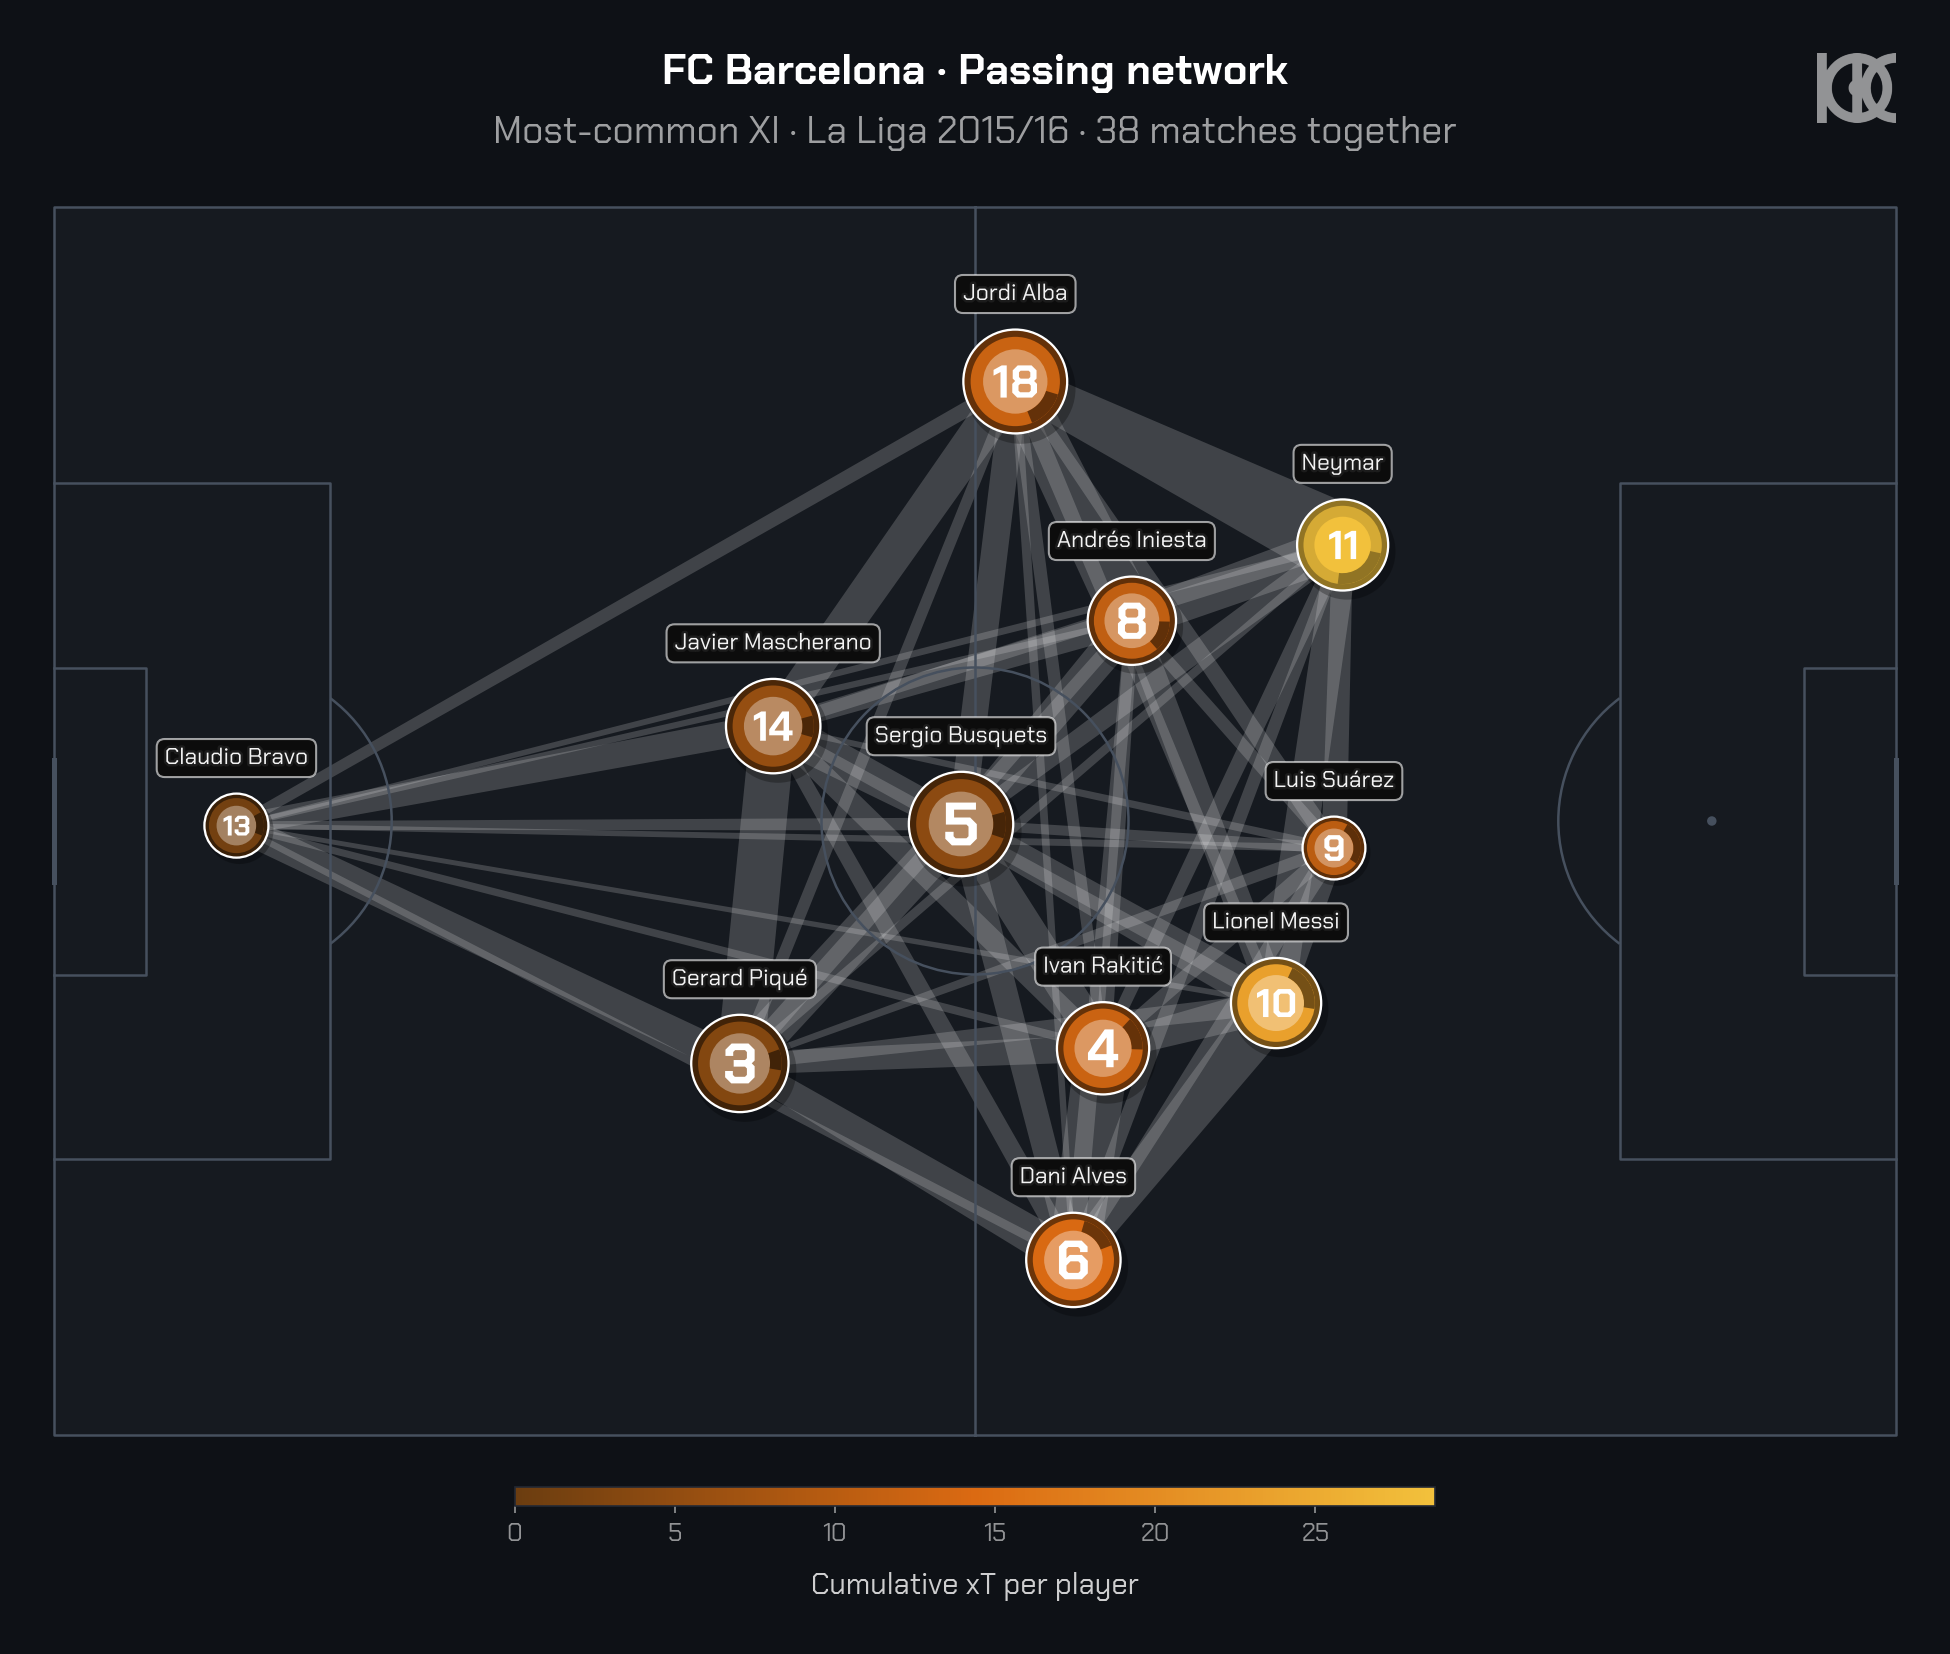

In [14]:
# Season-aggregated passing network — the most common starting XI over a full Barcelona season.
# Swap COMP_ID / SEASON_ID for any other season (StatsBomb open data covers La Liga 2004/05-2020/21).
COMP_ID, SEASON_ID, TEAM, SEASON_LABEL = 11, 27, "Barcelona", "La Liga 2015/16"

base_path = "path/to/statsbomb_open_data/data"

# every match the team played that season
with open(os.path.join(base_path, f"matches/{COMP_ID}/{SEASON_ID}.json")) as f:
    matches = json.load(f)
match_ids = [m["match_id"] for m in matches
             if TEAM in (m["home_team"]["home_team_name"], m["away_team"]["away_team_name"])]
print(f"Loading {len(match_ids)} {TEAM} matches …")

# most common XI + the passes they made while their starting block was intact, summed over the season
season_passes, core_ids, n_used, total_minutes = find_common_xi_and_passes(
    base_path, match_ids, TEAM, core_size=11)

# per-player display attributes from the lineup feed: usual jersey number (inside the chip) and the
# "known as" nickname (the pill label) — nickname falls back to the full name where StatsBomb has none
lineups = pd.concat([load_lineups(mid, base_path) for mid in match_ids])
jersey_map = (lineups.dropna(subset=["jersey_number"]).groupby("player_id")["jersey_number"]
              .agg(lambda s: s.mode().iloc[0]).to_dict())
name_map = {}
for pid, grp in lineups.groupby("player_id"):
    nick = grp["player_nickname"].dropna()
    name_map[pid] = nick.mode().iloc[0] if not nick.empty else grp["player_name"].iloc[0]

network_schema = get_passing_network_schema(season_passes, team_name=f"FC {TEAM}",
                                             jersey_map=jersey_map, name_map=name_map)
subtitle = f"Most-common XI · {SEASON_LABEL} · {n_used} matches together"
plot_passing_network(network_schema, subtitle=subtitle)

## Within a match: first half vs second half

Splitting a single match into its two halves shows how a team's **shape and connections evolve** across the 90 minutes — a side higher and wider after the break, a pivot dropping deeper, a supply line that only opens up late.

The honest way to handle **substitutions** is to show, in each half, the **eleven players who were actually on the pitch longest that half** (minutes = how much of the half a player's on-pitch spell covers). So every panel is a real, full XI: a substitute who plays most of the second half is *in*, a starter hooked early is *out* — no phantom 10-man networks.

Because a substituted player only appears for part of a half, their node and links are naturally smaller. We flag them so that's not mistaken for poor involvement: a small circle on the node — **green `→` for a player who came on, red `←` for one subbed off**, with the minute — marks exactly who was partial and when.

Both pitches are drawn on **one shared scale** — node size (pass volume), colour (xT) and edge width (link volume) are normalised across the two halves together, so a chip that looks bigger on the right genuinely *was* busier, not merely rescaled.

In [15]:
def half_lineups_passes_subs(base_path, match_id, team_name, boundary=45):
    """For EACH half, the truthful on-pitch XI plus sub flags.

    Handles substitutions honestly: for each half we take the 11 players who spent the LONGEST on the
    pitch that half (minutes = the overlap of a player's on-pitch interval with the half), so every panel
    is a full, real XI — a sub who plays most of the second half is in, a starter hooked early is out.
    Each half also records who arrived ('on') or departed ('off') during it, and the minute, so their
    partial-minute node/edges can be flagged with an icon. Returns {period: {ids, passes, subs}}."""
    df_passes = load_passes(match_id, base_path)
    df_app = load_appearances(match_id, base_path)
    team = df_app[df_app['team_name'] == team_name]
    match_end = team['end_minute'].max()

    out = {}
    for period, lo, hi in [(1, 0, boundary), (2, boundary, match_end + 1)]:
        minutes, subs = {}, {}
        for r in team.itertuples():
            played = max(0, min(r.end_minute, hi) - max(r.start_minute, lo))
            if played <= 0:
                continue
            minutes[r.player_id] = played
            if r.start_minute > 0 and lo <= r.start_minute < hi:          # arrived during this half
                subs[r.player_id] = ('on', int(r.start_minute))
            elif r.end_minute < match_end and lo <= r.end_minute < hi:     # departed during this half
                subs[r.player_id] = ('off', int(r.end_minute))
        top11 = sorted(minutes, key=minutes.get, reverse=True)[:11]
        passes = df_passes[(df_passes['team_name'] == team_name) &
                           (df_passes['player_id'].isin(top11)) &
                           (df_passes['period'] == period)].copy()
        out[period] = {"ids": top11, "passes": passes, "subs": subs}
    return out


def plot_halves(match_id, base_path, team_name, jersey_map=None, name_map=None, title=None, subtitle=None):
    """Two vertical pitches side by side — the truthful on-pitch XI (by minutes) in the first half (left)
    and second half (right), on ONE shared size/colour/edge scale so the halves are directly comparable.
    Substituted players carry a house node icon (kick_node_icon: green → came on, red ← subbed off) with
    the minute, to explain their partial-minute nodes."""
    halves = half_lineups_passes_subs(base_path, match_id, team_name)
    kw = dict(jersey_map=jersey_map, name_map=name_map)
    sch1 = get_passing_network_schema(halves[1]["passes"], **kw)
    sch2 = get_passing_network_schema(halves[2]["passes"], **kw)

    # ONE shared scale across both halves (else a bigger H1 node would just be rescaled away)
    max_passes = max(sch1["max_passes"], sch2["max_passes"], 1)
    vmax_xt = max(sch1["vmax_xt"], sch2["vmax_xt"])
    dirmax = max([max(e["v_1_to_2"], e["v_2_to_1"]) for s in (sch1, sch2) for e in s["edges"]] + [1])
    MAX_R, MIN_R = 3.4, 1.2

    pitch, fig, axes = kick_grid(1, 2, vertical=True, cbar=True, cbar_pos="bottom")
    for ax, sch, half, lbl in [(axes[0, 0], sch1, halves[1], "First half"),
                               (axes[0, 1], sch2, halves[2], "Second half")]:
        _draw_network(ax, sch, vmax_xt, max_passes, dirmax, vertical=True, name_size=9)
        for n in sch["nodes"]:                                          # sub icons on partial-minute players
            if n["player_id"] in half["subs"]:
                kind, minute = half["subs"][n["player_id"]]
                r = MIN_R + (MAX_R - MIN_R) * (n["pass_count"] / max_passes)
                kick_node_icon(ax, n["y"], n["x"], r, f"sub_{kind}", label=f"{minute}'")  # (x,y)->(y,x)
        kick_panel_label(ax, lbl)

    sm = cm.ScalarMappable(norm=mcolors.Normalize(0, vmax_xt), cmap=KICK_SEQ_WARM); sm.set_array([])
    kick_grid_cbar(fig, axes, sm, "Cumulative xT per player")
    kick_grid_title(fig, axes, title, subtitle)
    plt.show()

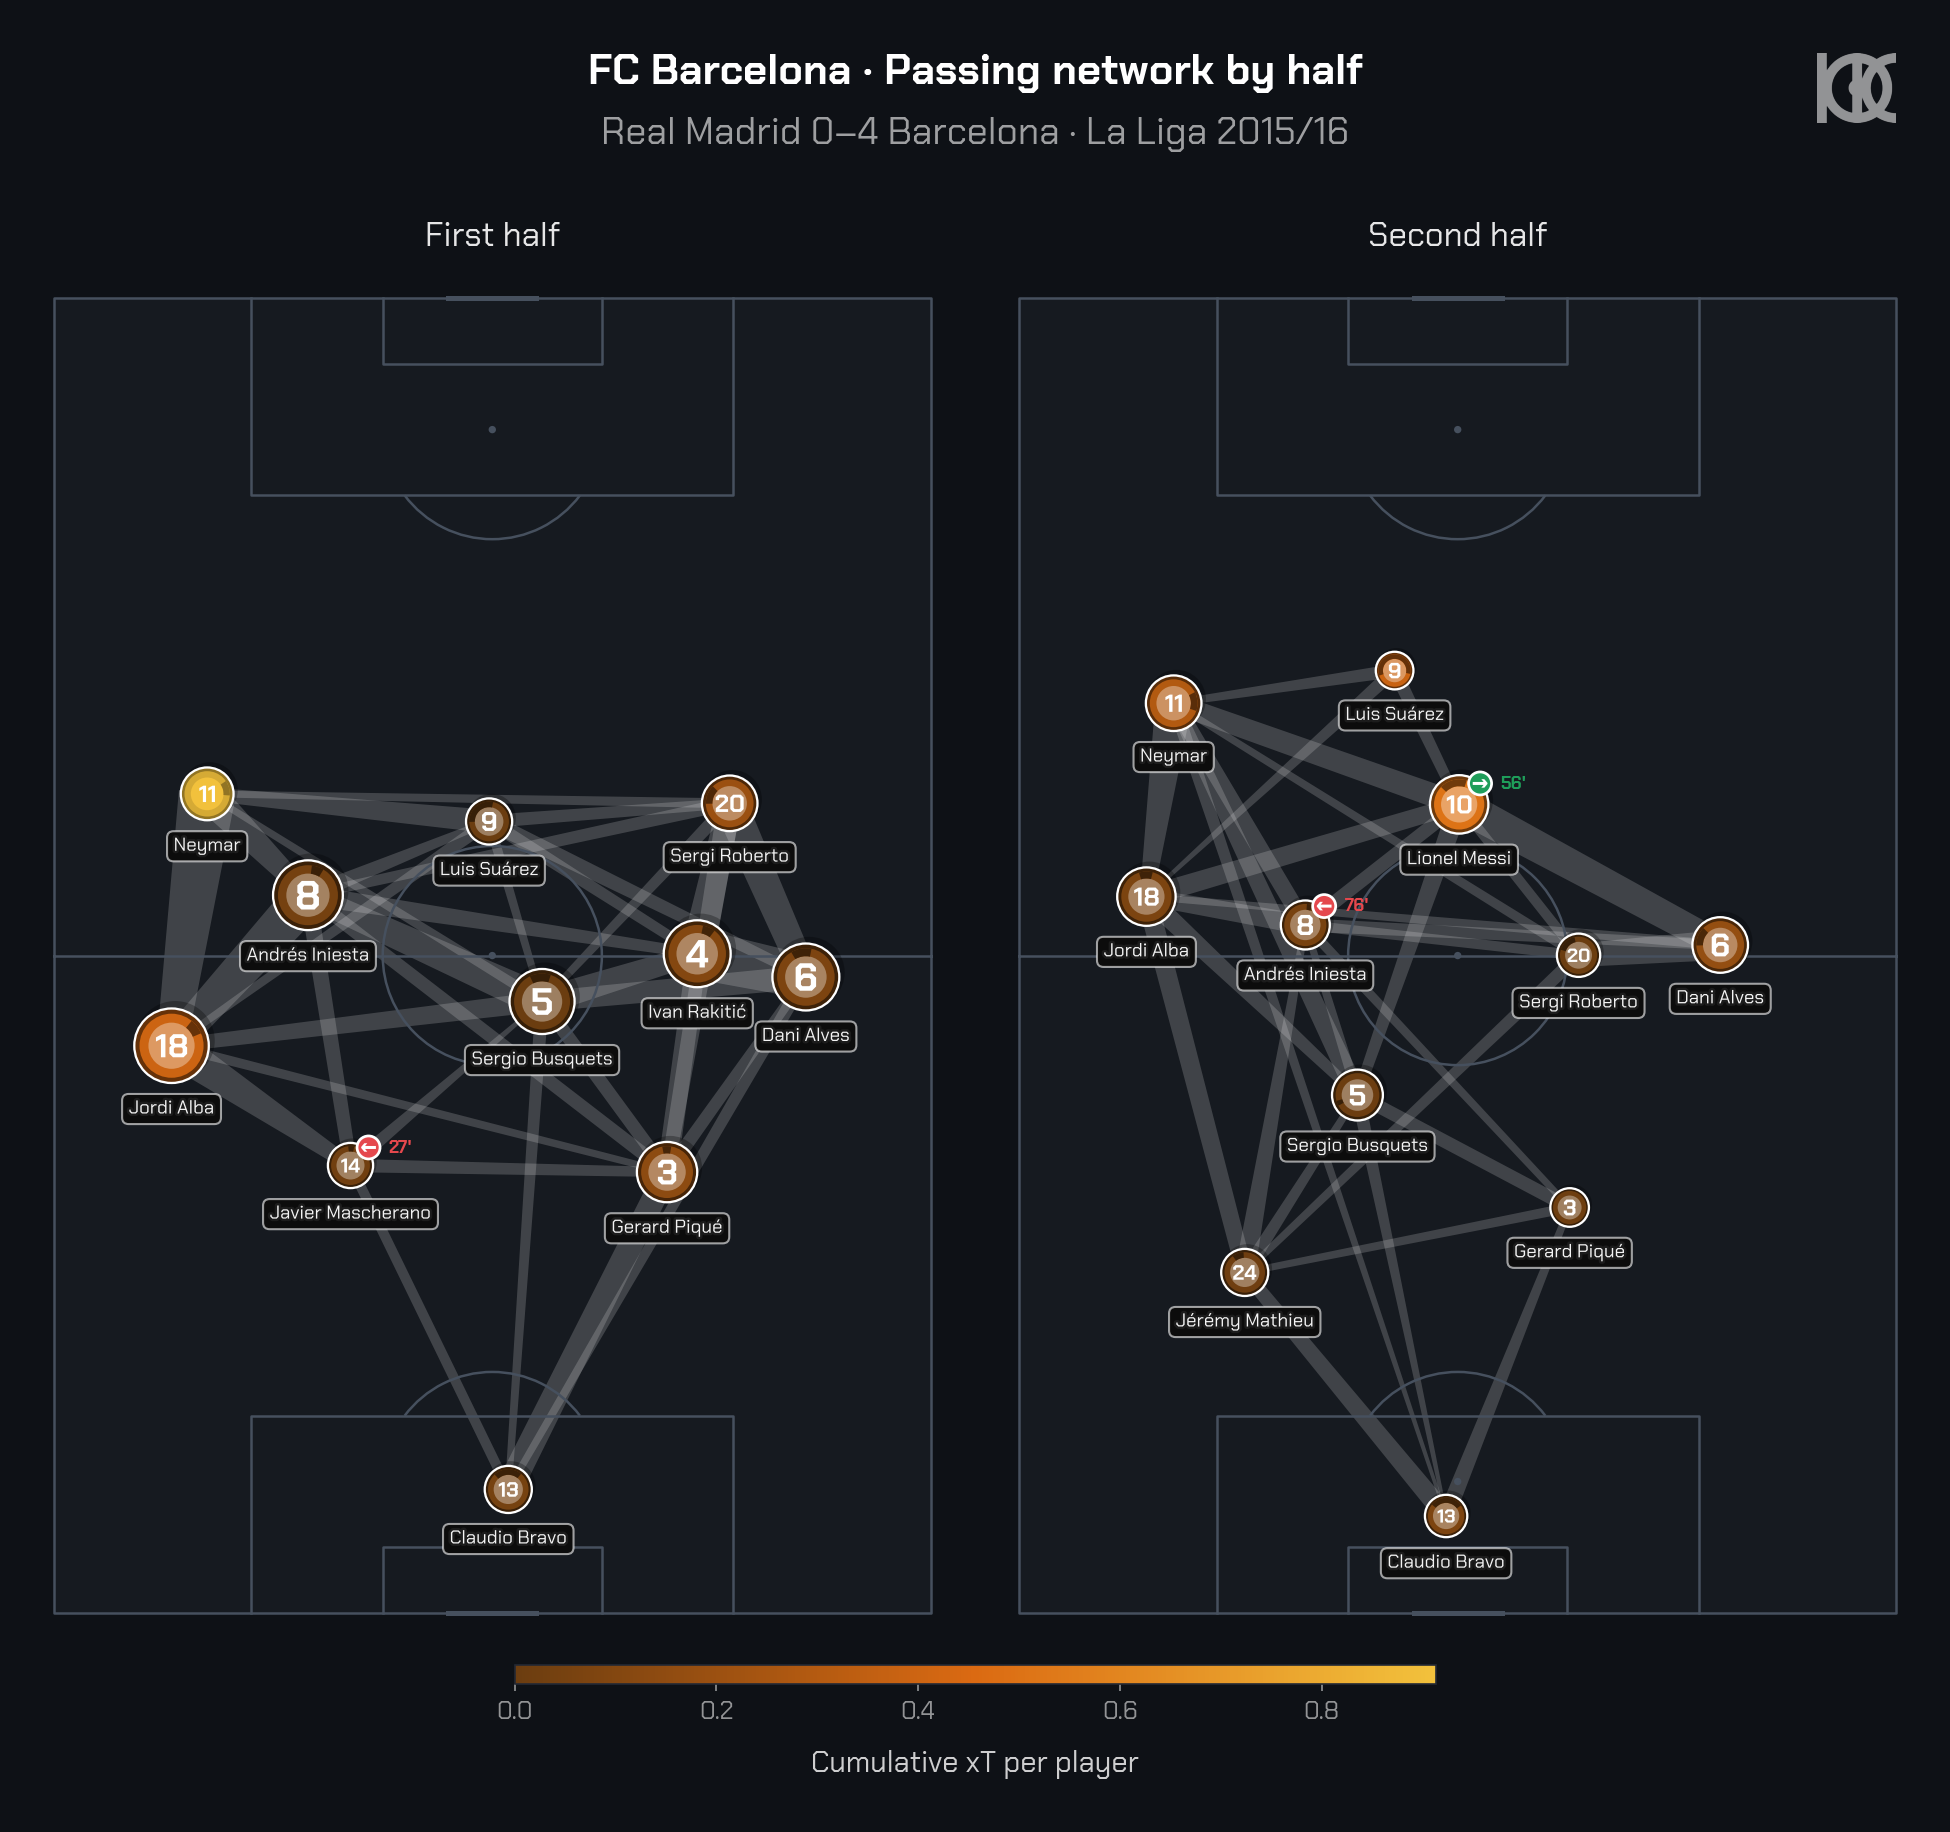

In [16]:
# A single match split into halves — the iconic Bernabéu Clásico, Real Madrid 0-4 Barcelona.
CLASICO_ID = 266424
base_path = "path/to/statsbomb_open_data/data"
TEAM = "Barcelona"

# jersey number + "known as" name for the chips (single-match lineup)
dl = load_lineups(CLASICO_ID, base_path)
jersey_map = dict(zip(dl["player_id"], dl["jersey_number"]))
name_map = {r.player_id: (r.player_nickname if pd.notna(r.player_nickname) else r.player_name)
            for r in dl.itertuples()}

plot_halves(CLASICO_ID, base_path, TEAM, jersey_map=jersey_map, name_map=name_map,
            title="FC Barcelona · Passing network by half",
            subtitle="Real Madrid 0–4 Barcelona · La Liga 2015/16")